## **Import packages and images**

In [ ]:
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.layers import Dense, Flatten, Dropout, RandomZoom, RandomContrast, RandomRotation
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img
from tensorflow.keras.models import Sequential
from numpy import expand_dims, asarray
from google.colab import drive
from random import *
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
!pip install split-folders
!pip install Pillow
from PIL import Image
import splitfolders

drive.mount('/content/gdrive')

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Mounted at /content/gdrive


In [ ]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
NUM_EPOCHS = 20

In [ ]:
splitfolders.ratio('/content/gdrive/MyDrive/research_paper_skin_cancer', output="output", seed=1337, ratio=(0.8,0.1,0.1))

train_path = 'output/train'
test_path = 'output/test'
val_path = 'output/val'

Copying files: 2109 files [00:36, 57.46 files/s] 


## **Augment training & testing images**

before training augmentation:


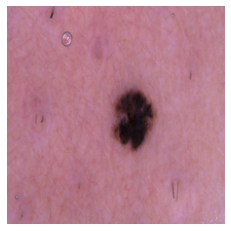

after training augmentation:


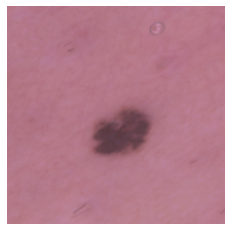

before training augmentation:


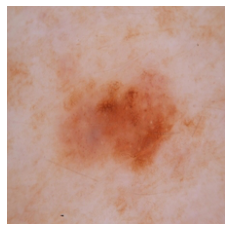

after training augmentation:


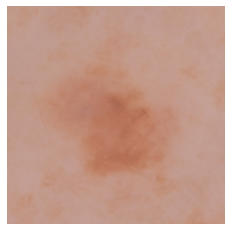

before training augmentation:


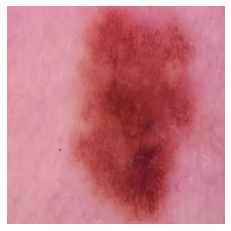

after training augmentation:


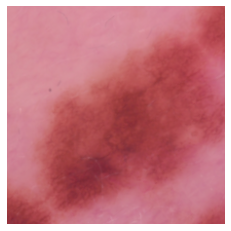

before training augmentation:


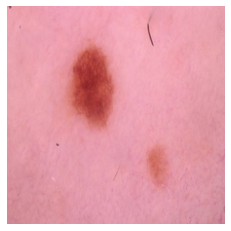

after training augmentation:


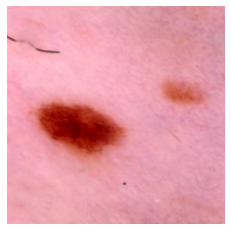

before training augmentation:


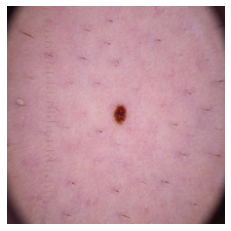

after training augmentation:


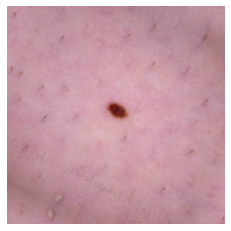

before training augmentation:


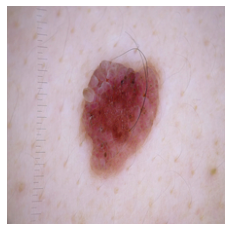

after training augmentation:


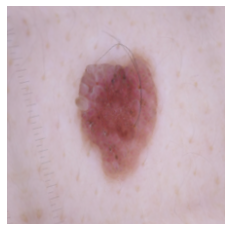

before training augmentation:


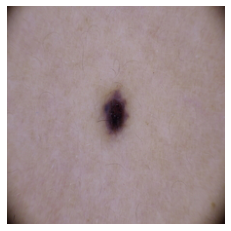

after training augmentation:


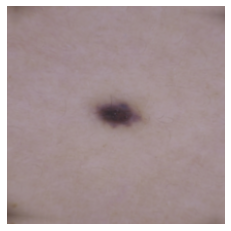

before training augmentation:


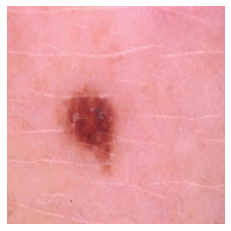

after training augmentation:


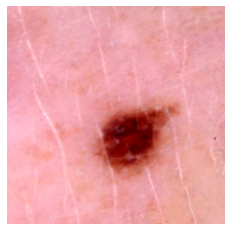

before training augmentation:


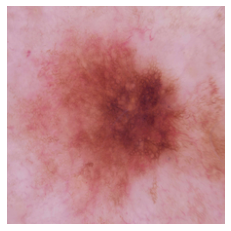

after training augmentation:


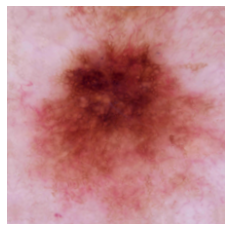

before training augmentation:


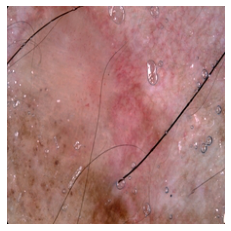

after training augmentation:


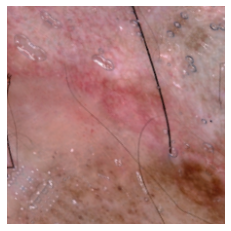

before training augmentation:


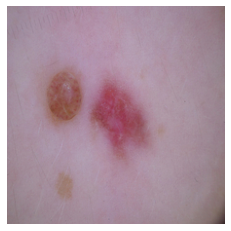

after training augmentation:


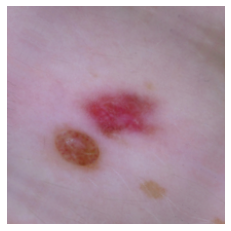

before training augmentation:


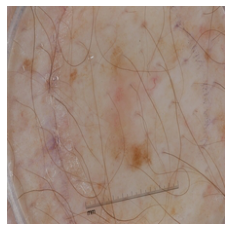

after training augmentation:


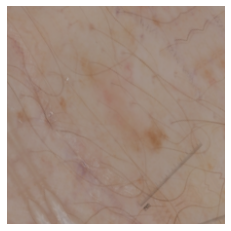

before training augmentation:


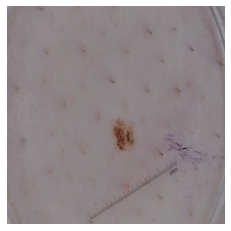

after training augmentation:


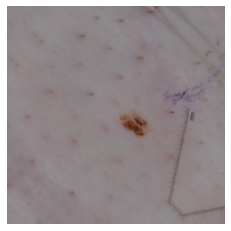

before training augmentation:


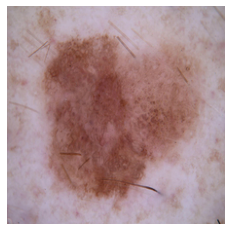

after training augmentation:


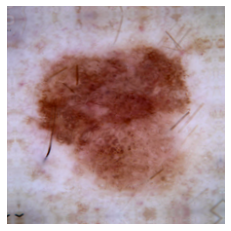

before training augmentation:


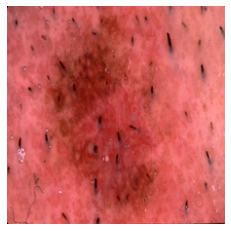

after training augmentation:


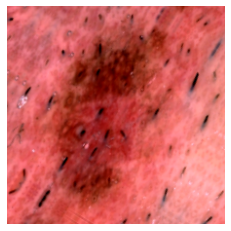

before training augmentation:


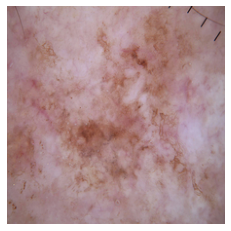

after training augmentation:


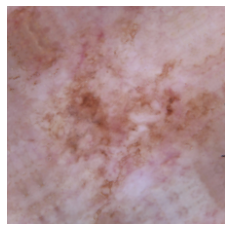

before training augmentation:


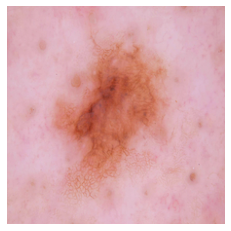

after training augmentation:


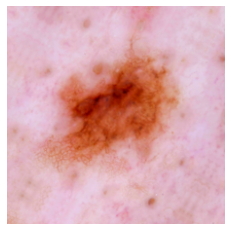

before augmentation:


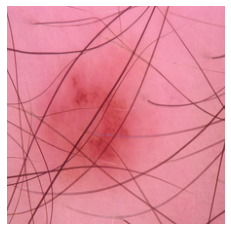

after augmentation:


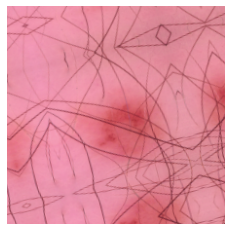

before augmentation:


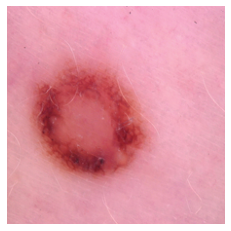

after augmentation:


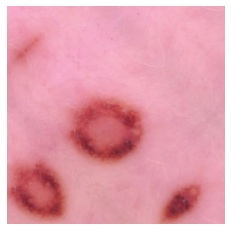

before augmentation:


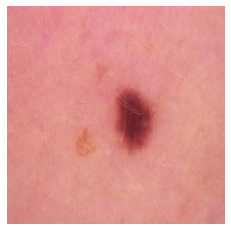

after augmentation:


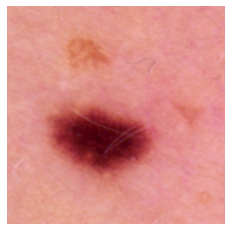

before augmentation:


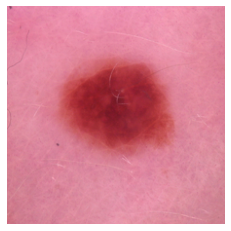

after augmentation:


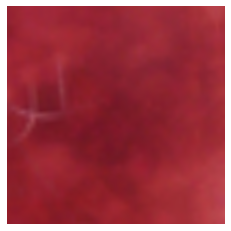

before augmentation:


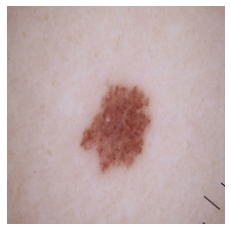

after augmentation:


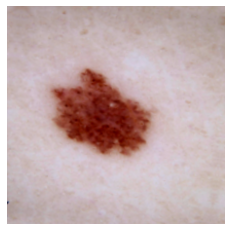

before augmentation:


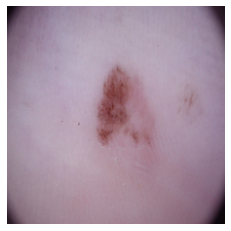

after augmentation:


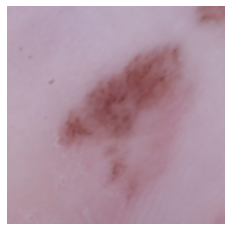

before augmentation:


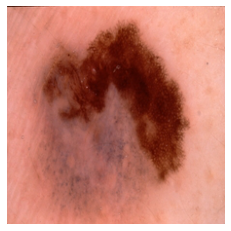

after augmentation:


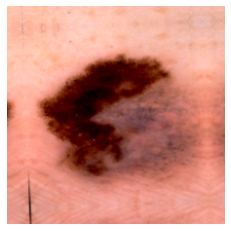

before augmentation:


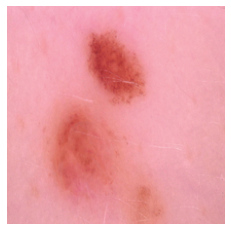

after augmentation:


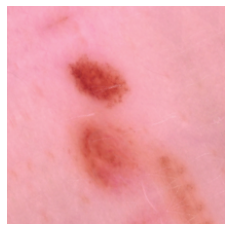

before augmentation:


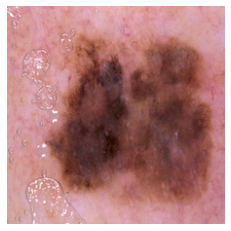

after augmentation:


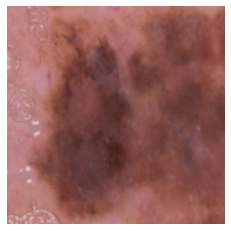

before augmentation:


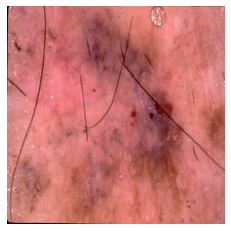

after augmentation:


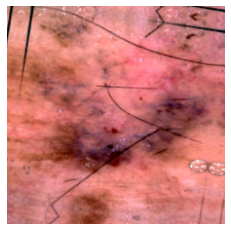

before augmentation:


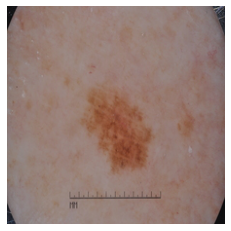

after augmentation:


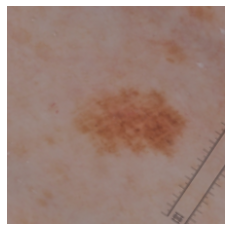

In [ ]:
train_mal_size_augmentation = RandomZoom(height_factor=(0, 0.1), width_factor=(0, 0.1))
train_ben_size_augmentation = RandomZoom(height_factor=(-0.1, 0), width_factor=(-0.1, 0))

size_augmentation = RandomZoom(0.8)
contrast_augmentation = RandomContrast(0.6)
rotation_augmentation = RandomRotation(0.3)


def augment_image(np_image):

    num = randint(1, 50)

    if num == 5:
        print('before augmentation:')
        plt.axis('off')
        plt.imshow(np_image)
        plt.show()

    # Random size
    augmented_eager_tensor = size_augmentation(np_image)
    augmented_np_arr = augmented_eager_tensor.numpy()

    # Random contrast
    augmented_eager_tensor = contrast_augmentation(augmented_np_arr)
    augmented_np_arr = augmented_eager_tensor.numpy()

    # Random rotation
    augmented_eager_tensor = rotation_augmentation(augmented_np_arr)
    augmented_np_arr = augmented_eager_tensor.numpy()

    if num == 5:
        print('after augmentation:')
        plt.axis('off')
        plt.imshow(augmented_np_arr / 255)
        plt.show()

    return augmented_np_arr


for folder in os.listdir(train_path):
    sub_path = train_path + '/' + folder
    for img in os.listdir(sub_path):
        num = randint(1, 100)

        pil_img = Image.open(sub_path+'/'+img)
        os.remove(sub_path+'/'+img)
        np_image = asarray(pil_img)

        if num == 5:
            print('before training augmentation:')
            plt.axis('off')
            plt.imshow(np_image)
            plt.show()

        # Random size
        if (folder == 'malignant'):
            augmented_eager_tensor = train_mal_size_augmentation(np_image)
        else:
            augmented_eager_tensor = train_ben_size_augmentation(np_image)
        augmented_arr = augmented_eager_tensor.numpy()

        # Random contrast
        augmented_eager_tensor = contrast_augmentation(augmented_arr)
        augmented_arr = augmented_eager_tensor.numpy()

        # Random rotation
        augmented_eager_tensor = rotation_augmentation(augmented_arr)
        augmented_arr = augmented_eager_tensor.numpy()

        if num == 5:
            print('after training augmentation:')
            plt.axis('off')
            plt.imshow(augmented_arr / 255)
            plt.show()

        augmented_image = Image.fromarray(augmented_arr.astype(np.uint8))

        fullpath = os.path.join(sub_path, 'new_' + img)
        augmented_image.save(fullpath)


for folder in os.listdir(test_path):
    sub_path = test_path+'/'+folder
    for img in os.listdir(sub_path):
        pil_img = Image.open(sub_path+'/'+img)
        os.remove(sub_path+'/'+img)
        np_image = asarray(pil_img)

        augmented_arr = augment_image(np_image)

        augmented_image = Image.fromarray(augmented_arr.astype(np.uint8))

        fullpath = os.path.join(sub_path, 'new_' + img)
        augmented_image.save(fullpath)
        

for folder in os.listdir(val_path):
    sub_path = val_path+'/'+folder
    for img in os.listdir(sub_path):
        pil_img = Image.open(sub_path+'/'+img)
        os.remove(sub_path+'/'+img)
        np_image = asarray(pil_img)

        augmented_arr = augment_image(np_image)

        augmented_image = Image.fromarray(augmented_arr.astype(np.uint8))

        fullpath = os.path.join(sub_path, 'new_' + img)
        augmented_image.save(fullpath)

In [ ]:
DATAGEN = ImageDataGenerator(rescale = 1./255, validation_split=0.2)


training_set = DATAGEN.flow_from_directory(train_path,
                                                 target_size = IMAGE_SIZE,
                                                 batch_size = BATCH_SIZE,
                                                 class_mode = 'categorical')

test_set = DATAGEN.flow_from_directory(test_path,
                                            target_size = IMAGE_SIZE,
                                            batch_size = BATCH_SIZE,
                                            class_mode = 'categorical')

val_set = DATAGEN.flow_from_directory(val_path,
                                            target_size = IMAGE_SIZE,
                                            batch_size = BATCH_SIZE,
                                            class_mode = 'categorical')

Found 1686 images belonging to 2 classes.
Found 213 images belonging to 2 classes.
Found 210 images belonging to 2 classes.


## **Initialize VGG19 DCNN model, trained on ImageNet**

In [ ]:
vgg_19 = VGG19(weights='imagenet', include_top=False, input_shape = (224,224,3))

80134624/80134624 [==============================] - 4s 0us/step


In [ ]:
set_trainable = False
for layer in vgg_19.layers:
    layer.trainable = False

In [ ]:
model = models.Sequential()

model.add(vgg_19)

model.add(layers.Flatten())

model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(2, activation='softmax'))

In [ ]:
model.compile(
  loss = 'categorical_crossentropy',
  optimizer = optimizers.Adam(lr=2e-5),
  metrics = ['acc']
)

/usr/local/lib/python3.7/dist-packages/keras/optimizers/optimizer_v2/adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [ ]:
history = model.fit(
  training_set,
  steps_per_epoch = training_set.samples // BATCH_SIZE,
  epochs = NUM_EPOCHS,
  validation_data = val_set,
  validation_steps = val_set.samples // BATCH_SIZE,
  shuffle = True
  )

Epoch 1/20
52/52 [==============================] - 22s 237ms/step - loss: 0.6709 - acc: 0.6010 - val_loss: 0.6222 - val_acc: 0.6979
Epoch 2/20
52/52 [==============================] - 10s 192ms/step - loss: 0.6285 - acc: 0.6542 - val_loss: 0.5735 - val_acc: 0.7135
Epoch 3/20
52/52 [==============================] - 10s 193ms/step - loss: 0.5986 - acc: 0.6856 - val_loss: 0.5685 - val_acc: 0.7188
Epoch 4/20
52/52 [==============================] - 10s 193ms/step - loss: 0.5600 - acc: 0.7189 - val_loss: 0.5322 - val_acc: 0.7396
Epoch 5/20
52/52 [==============================] - 10s 197ms/step - loss: 0.5519 - acc: 0.7310 - val_loss: 0.5052 - val_acc: 0.7552
Epoch 6/20
52/52 [==============================] - 10s 195ms/step - loss: 0.5335 - acc: 0.7382 - val_loss: 0.4761 - val_acc: 0.7760
Epoch 7/20
52/52 [==============================] - 10s 195ms/step - loss: 0.5123 - acc: 0.7648 - val_loss: 0.4670 - val_acc: 0.7865
Epoch 8/20
52/52 [==============================] - 10s 197ms/step - 

## **Plot accuracy before Transfer Learning**

In [ ]:
def plot_acc_loss(history):
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

# summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

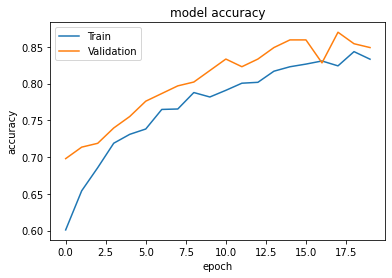

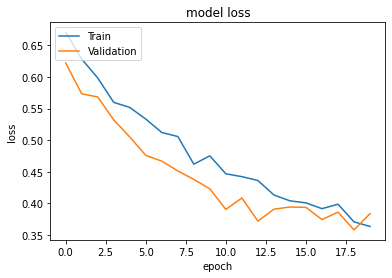

In [ ]:
plot_acc_loss(history)

In [ ]:
test_loss, test_acc = model.evaluate(test_set, steps=test_set.samples // BATCH_SIZE)
print(f"Test Accuracy before fine tuning: {test_acc*100:.2f} %")

6/6 [==============================] - 1s 175ms/step - loss: 0.4150 - acc: 0.7917
Test Accuracy before fine tuning: 79.17 %


## **Fine-tune hyperparameters to optimize performance**

In [ ]:
vgg_19.trainable = True

set_trainable = False
for layer in vgg_19.layers:
    if layer.name=='block5_conv1':
        set_trainable = True
    if set_trainable == True:
        layer.trainable = True
    else:
        layer.trainable = False

In [ ]:
model.compile(
  loss = 'categorical_crossentropy',
  optimizer = optimizers.Adam(lr=2e-5),
  metrics = ['acc']
)

In [ ]:
history = model.fit(
  training_set,
  steps_per_epoch = training_set.samples // BATCH_SIZE,
  epochs = NUM_EPOCHS,
  validation_data = val_set,
  validation_steps = val_set.samples // BATCH_SIZE,
  shuffle = True
  )

Epoch 1/20
52/52 [==============================] - 14s 232ms/step - loss: 0.3893 - acc: 0.8162 - val_loss: 0.3281 - val_acc: 0.8490
Epoch 2/20
52/52 [==============================] - 12s 224ms/step - loss: 0.3336 - acc: 0.8537 - val_loss: 0.3419 - val_acc: 0.8698
Epoch 3/20
52/52 [==============================] - 12s 225ms/step - loss: 0.2756 - acc: 0.8833 - val_loss: 0.3174 - val_acc: 0.8542
Epoch 4/20
52/52 [==============================] - 12s 225ms/step - loss: 0.2373 - acc: 0.8984 - val_loss: 0.3270 - val_acc: 0.8646
Epoch 5/20
52/52 [==============================] - 12s 225ms/step - loss: 0.1998 - acc: 0.9129 - val_loss: 0.4254 - val_acc: 0.8333
Epoch 6/20
52/52 [==============================] - 12s 225ms/step - loss: 0.2028 - acc: 0.9196 - val_loss: 0.4031 - val_acc: 0.8698
Epoch 7/20
52/52 [==============================] - 12s 225ms/step - loss: 0.1680 - acc: 0.9389 - val_loss: 0.4767 - val_acc: 0.8385
Epoch 8/20
52/52 [==============================] - 12s 227ms/step - 

## **Plot accuracy after Transfer Learning**

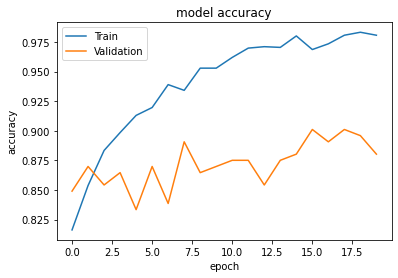

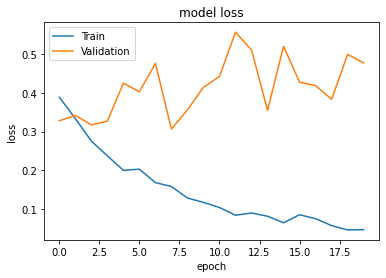

In [ ]:
plot_acc_loss(history)

In [ ]:
test_loss, test_acc = model.evaluate(test_set, steps=test_set.samples // BATCH_SIZE)
print(f"Test Accuracy After fine tuning: {test_acc*100:.2f} %")

6/6 [==============================] - 1s 171ms/step - loss: 1.1520 - acc: 0.8021
Test Accuracy After fine tuning: 80.21 %
